# Laboppgave 1: Sampling og frekvensinnhold

**Lab 1, PHYS116**  
**Navn:** Aksel Tristan Skår Villoing, Alex Thorseth, Joar Nikolai Borlaug
**Dato:** 24.08.26



## Erklæring

### Erklæring om arbeidsfordeling
Arbeidet i gruppen har vært fordelt omtrent likt. Programmeringen har gruppen gjort sammen, og diskusjonsdelen er blitt diskutert og skrevet sammen. Resten av delene i rapporten er fordelt omtrent likt.

### Erklæring om bruk av KI
Kunstig intelligens er brukt for feilsøking i programmer, tilpasning av grafer, og til hjelp med latex formuleringer for markdown tekstbokser. Verktøyet brukt for alle oppgavene er GPT-5.6 Sol.




## Målsetting

Målet med labortatorieøvelsen er å undersøke hvordan periodiske signaler representeres når det måles digitalt. For å gjøre dette skal man generere ulike typer signaler, undersøke ulike samplingfrekvenser og sammenligne resultater i tidsdomenet og frekvensdomenet. I øvelsen blir sammenheng mellom frekvens, periode, fase og FFT-spekter undersøkt. I tillegg blir også fenomenet aliasing sett på.



## 1. Metode


Laboratorieøvelsen ble gjennomført i Python i en Jupyter Notebook ved bruk av NumPy og Matplotlib. Signalene ble generert digitalt og undersøkt  i tidsdomenet og i frekvensdomenet.

### 1.1 Referansemåling

Først ble funksjonen syn_sin() brukt til å generere signaler fra oppgitte frekvenser, amplituder og faser. Funksjonen lager en tidsakse ut fra samplingsfrekvensen og signalets varighet, og summerer deretter de ulike frekvenskomponentene til ett samlet signal. Referansesignalet besto av frekvensene 100 Hz, 700 Hz og 1100 Hz, med amplitudene 2,0 V, 1,0 V og 0,5 V. 

Signalene ble generert med en samplingsfrekvens på 5000 Hz og en varighet på 0,05 s.For å undersøke frekvensinnholdet ble funksjonen amplitude_spectrum() brukt. Her ble middelverdien til signalet først trukket fra, før np.fft.rfft() ble brukt til å beregne et enkeltsidig frekvensspekter. Frekvensaksen ble laget med np.fft.rfftfreq(), og amplitudene ble normalisert slik at verdiene i spekteret kunne sammenlignes med amplitudene som ble brukt til å lage signalet.

Funksjonen plott_tid_og_spekter() ble brukt til å vise signalet både i tidsdomenet og frekvensdomenet (figur 1). Et kort utsnitt av signalet ble vist med tid i millisekunder, mens frekvensspekteret ble vist opp til Nyquist-frekvensen. Nyquist-frekvensen ble også markert i plottet.

Ved referansemålingen ble antall sampler og frekvensoppløsningen skrevet ut. Amplitudene ved 100 Hz, 700 Hz og 1100 Hz ble hentet fra FFT-spekteret og sammenlignet med de opprinnelige amplitudene som ble brukt til å generere signalet.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def syn_sin(fk, Xk, fs, dur, tstart=0.0):
    """
    Syntetiserer et signal basert på gitte frekvenser og komplekse amplituder.

    Args:
        fk (array-like): Frekvensene til de harmoniske komponentene.
        Xk (array-like): Komplekse amplituder for de harmoniske komponentene.
        fs (float): Samplingsfrekvens.
        dur (float): Varighet av signalet i sekunder.
        tstart (float, optional): Starttid for signalet. Default er 0.

    Returns:
        tuple: En tuple som inneholder:
            - xx (numpy.ndarray): Det syntetiserte signalet.
            - tt (numpy.ndarray): Tidsvektor for signalet.
    """
    fk = np.asarray(fk, dtype=float)
    Xk = np.asarray(Xk, dtype=complex)

    N = int(round(fs * dur))
    tt = tstart + np.arange(N) / fs

    amplitudes = np.abs(Xk)[:, None]
    phases = np.angle(Xk)[:, None]
    frequencies = fk[:, None]

    xx = np.sum( amplitudes * np.cos(2 * np.pi * frequencies * tt + phases), axis=0, )

    return xx, tt

In [ ]:
def amplitude_spectrum(signal, fs: float):
    """
    Beregner frekvensakse og normalisert enkeltsidig amplitudespekter
    til et signal ved hjelp av Fouriertransformasjon.

    Args:
        signal (array-like): Signalverdiene som skal analyseres.
        fs: Samplingsfrekvensen i Hz.

    Returns:
        tuple: En tuple som inneholder:
            - frekvens (numpy.ndarray): Frekvensverdiene i Hz.
            - amplitude (numpy.ndarray): Det normaliserte enkeltsidige
              amplitudespekteret.
    """
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    antall_sampler = len(signal)
    transform = np.fft.rfft(signal)
    frekvens = np.fft.rfftfreq(antall_sampler, d=1 / fs)

    amplitude = 2 * np.abs(transform) / antall_sampler
    amplitude[0] /= 2

    if antall_sampler % 2 == 0:
        amplitude[-1] /= 2

    return frekvens, amplitude

In [6]:
def plott_tid_og_spekter(
    signal,
    tid,
    fs: float,
    tittel: str,
    tidsvindu_ms: float = 20,
):
    """
    Plotter et kort utsnitt av signalet i tidsdomenet og
    det normaliserte enkeltsidige amplitudespekteret.

    Args:
        signal (array-like): Signalverdiene som skal plottes og analyseres.
        tid (array-like): Tidsverdiene som tilhører signalet, oppgitt i sekunder.
        fs (float): Samplingsfrekvensen i Hz.
        tittel (str): Tittel som vises øverst på figuren.
        tidsvindu_ms (float, optional): Lengden på tidsutsnittet som vises,
            oppgitt i millisekunder. Default er 20.

    Returns:
        tuple: En tuple som inneholder:
            - frekvens (numpy.ndarray): Frekvensverdiene i Hz.
            - amplitude (numpy.ndarray): Det normaliserte enkeltsidige
              amplitudespekteret.
    """
    frekvens, amplitude = amplitude_spectrum(signal, fs)
    nyquist = fs / 2

    figur, akser = plt.subplots(1, 2, figsize=(12, 4))

    utsnitt = tid * 1000 <= tidsvindu_ms
    akser[0].plot(tid[utsnitt] * 1000, signal[utsnitt], lw=1.4)
    akser[0].set_xlabel("Tid [ms]")
    akser[0].set_ylabel("Amplitude [V]")
    akser[0].set_title("Tidsdomene")

    akser[1].stem(frekvens, amplitude, basefmt=" ")
    akser[1].axvline(
        nyquist,
        color="crimson",
        ls="--",
        lw=1.4,
        label=f"Nyquist = {nyquist:g} Hz",
    )
    akser[1].set_xlim(0, nyquist)
    akser[1].set_xlabel("Frekvens [Hz]")
    akser[1].set_ylabel("Amplitude [V]")
    akser[1].set_title("Frekvensdomene")
    akser[1].legend()

    figur.suptitle(tittel)
    figur.tight_layout()
    plt.show()

    return frekvens, amplitude

In [ ]:
FREKVENSER = np.array([100, 700, 1100], dtype=float)
AMPLITUDER = np.array([2.0, 1.0, 0.5], dtype=float)
FASER = np.array([np.pi / 4, 0, -np.pi / 2])
KOMPLEKSE_AMPLITUDER = AMPLITUDER * np.exp(1j * FASER)

REFERANSE_FS = 5000
MAALETID = 0.05

def referansemåling() -> None:
    """
    Genererer referansesignalet, plotter signalet i tids- og
    frekvensdomenet, og skriver ut måledata.

    Args:
        Ingen.

    Returns:
        None: Funksjonen returnerer ingen verdi.
    """

    signal, tid = syn_sin(FREKVENSER, KOMPLEKSE_AMPLITUDER, REFERANSE_FS, MAALETID)
    frekvens, amplitude = plott_tid_og_spekter(
        signal,
        tid,
        REFERANSE_FS,
        "Referansemåling: fs = 5000 Hz",
    )

    print(f"Antall sampler: {len(signal)}")
    print(f"Frekvensoppløsning: {frekvens[1] - frekvens[0]:.1f} Hz")

    for forventet in FREKVENSER:
        indeks = np.argmin(np.abs(frekvens - forventet))
        print(
            f"{forventet:4.0f} Hz -> målt amplitude "
            f"{amplitude[indeks]:.3f} V"
        )



### 1.2 Aliasing av sammensatte sinuser

For å undersøke aliasing ble det samme signalet generert med samplingsfrekvensene 5000 Hz, 2500 Hz, 1600 Hz, 1200 Hz og 1100 Hz. For hver samplingsfrekvens ble det laget tids- og frekvensplott. Funksjonen aliasfrekvens() ble brukt til å beregne hvilken frekvens en komponent ville observeres som dersom den ble foldet grunnet aliasing. Alle plottene er vist i figur 2.

In [9]:
def aliasfrekvens(frekvens: float, fs: float) -> float:
    """
    Beregner hvilken frekvens som observeres etter aliasering.
    Resultatet ligger mellom 0 Hz og Nyquist-frekvensen.

    Args:
        frekvens (float): Den opprinnelige frekvensen i Hz.
        fs (float): Samplingsfrekvensen i Hz.

    Returns:
        float: Den observerte aliasfrekvensen i Hz.
    """

    foldet = (frekvens + fs / 2) % fs - fs / 2

    return float(abs(foldet))

In [ ]:
SAMPLINGSFREKVENSER = [5000, 2500, 1600, 1200, 1100]

def Alias() -> None:
    """
        Genererer de 5 signalene, plotter signalene i tids- og
        frekvensdomenet, og skriver ut måledata.
    
        Args:
            Ingen.
    
        Returns:
            None: Funksjonen returnerer ingen verdi.
        """
    for fs in SAMPLINGSFREKVENSER:
        signal, tid = syn_sin(
            FREKVENSER,
            KOMPLEKSE_AMPLITUDER,
            fs,
            MAALETID,
        )
        plott_tid_og_spekter(
            signal,
            tid,
            fs,
            f"Sammensatt signal: fs = {fs} Hz",
        )

        aliaser = [aliasfrekvens(frekvens, fs) for frekvens in FREKVENSER]
        print(
            f"fs={fs:4d} Hz, Nyquist={fs/2:6.0f} Hz, "
            f"forventede frekvenser={aliaser}"
        )

### 1.3 Firkantsignal og harmoniske komponenter

Til slutt ble et firkantsignal laget med funksjonen syntetiser_firkantsignal(). Funksjonen genererer de odde harmoniske komponentene til et firkantsignal, beregner tilhørende amplituder og faser, og bruker deretter syn_sin() til å summere komponentene til ett signal.

Firkantsignalet ble først undersøkt med 2  og 5 harmoniske komponenter ved en samplingsfrekvens på 5000 Hz (figur 3 og 4). Deretter ble 3 harmoniske komponenter brukt med samplingsfrekvensene 5000 Hz, 2500 Hz, 1200 Hz og 1000 Hz (figur 5). For hver samplingsfrekvens ble det undersøkt hvilke harmoniske komponenter som lå under, på eller over Nyquist-frekvensen, og aliasfrekvensene til komponentene over Nyquist-frekvensen ble beregnet. 

In [ ]:
SAMPLINGSFREKVENSER = [5000, 2500, 1200, 1000]
ANTALL_HARMONISKE = 10                                 #N

def syntetiser_firkantsignal(
    antall_harmoniske: int,
    fs: float,
    dur: float,
    f0: float = 500,
    A: float = 1.0,
):
    """
    Genererer en tilnærming til et symmetrisk firkantsignal
    ved hjelp av odde harmoniske frekvenskomponenter.

    Args:
        antall_harmoniske (int): Antall harmoniske komponenter som skal brukes.
        fs (float): Samplingsfrekvensen i Hz.
        dur (float): Varigheten til signalet i sekunder.
        f0 (float, optional): Grunnfrekvensen til firkantsignalet i Hz.
            Default er 500 Hz.
         A (float, optional): Amplituden til firkantsignalet.
            Default er 1.0.


    Returns:
        tuple: En tuple som inneholder:
            - signal (numpy.ndarray): Det genererte firkantsignalet.
            - tid (numpy.ndarray): Tidsverdiene til signalet.
            - harmoniske (numpy.ndarray): Frekvensene til de odde harmoniske.
            - amplituder (numpy.ndarray): Amplitudene til de harmoniske komponentene.
    """
    
    tallrekke = np.arange(1, antall_harmoniske + 1)
    oddetall = 2 * tallrekke - 1                        #n

    harmoniske = oddetall * f0
    amplituder = 4 * A / (np.pi * oddetall)
    faser = np.full(antall_harmoniske, -np.pi / 2)
    komplekse_amplituder = amplituder * np.exp(1j * faser)

    signal, tid = syn_sin(harmoniske, komplekse_amplituder, fs, dur)
    return signal, tid, harmoniske, amplituder



def firkantsignal() -> None:
    """
    Genererer de 5 signalene, plotter signalene i tids- og
            frekvensdomenet, og skriver ut måledata.
        
            Args:
                Ingen.
        
            Returns:
                None: Funksjonen returnerer ingen verdi.
    """
    
    for fs in SAMPLINGSFREKVENSER:
        signal, tid, harmoniske, _ = syntetiser_firkantsignal(
            ANTALL_HARMONISKE,
            fs,
            dur=0.02,
        )
        plott_tid_og_spekter(
            signal,
            tid,
            fs,
            f"Firkantsignal: N = {ANTALL_HARMONISKE}, fs = {fs} Hz",
            tidsvindu_ms=8,
        )

        under = harmoniske[harmoniske < fs / 2]
        paa_nyquist = harmoniske[np.isclose(harmoniske, fs / 2)]
        over = harmoniske[harmoniske > fs / 2]
        aliaser = [aliasfrekvens(frekvens, fs) for frekvens in over]

        print(f"fs = {fs} Hz")
        print("  Under Nyquist:", under.tolist())
        print("  På Nyquist:", paa_nyquist.tolist())
        print("  Over Nyquist:", over.tolist())
        print("  Aliasfrekvenser:", aliaser)



## 2. Resultater

### 2.1 Referansemåling

Ser at referansesignalet har 3 frekvenskomponenter, 100 Hz, 700 Hz og 1100 Hz, som er forventet.


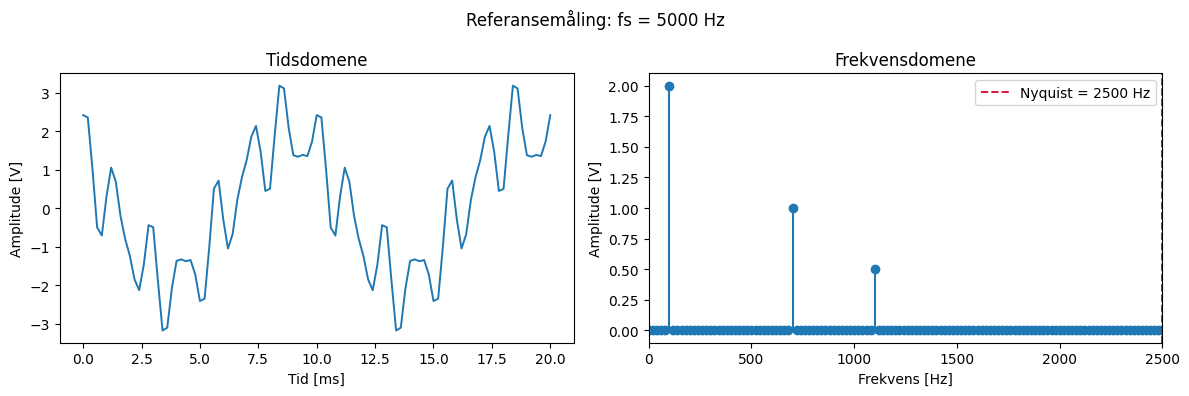

Antall sampler: 250
Frekvensoppløsning: 20.0 Hz
 100 Hz -> målt amplitude 2.000 V
 700 Hz -> målt amplitude 1.000 V
1100 Hz -> målt amplitude 0.500 V


In [8]:
referansemåling()

**Figur 1:**
Figuren viser referansesignalet sitt tidsplott til venstre og enkeltsidig amplitudespekter til høyre.



### 2.2 Aliasing

Gjennom alle samplingsfrekvensene kan man se på tidsdomenet at hovedfrekvensen, 100 Hz, holder seg uendret. Man kan se at samplingsfrekvens på både 5000 Hz og 2500 Hz beholder alle de samme frekvensene som referansemålingen. Ved samplingfrekvens på 1600 Hz blir 1100 Hz frekvenskomponenten foldet ned til et signal på 500 Hz. Det samme ser man med samplingfrekvens på 1200 Hz og 1100 Hz, der 1100 Hz frekvenskomponenten henholdsvis blir foldet til 100 Hz og 0 Hz, når den foldes til 100 Hz ser man at amplituden til frekvenskomponenten ved 100 Hz blir høyere. Ved de to siste blir også 700 hz frekvenskomponenten foldet til 500 Hz og 400 Hz. 

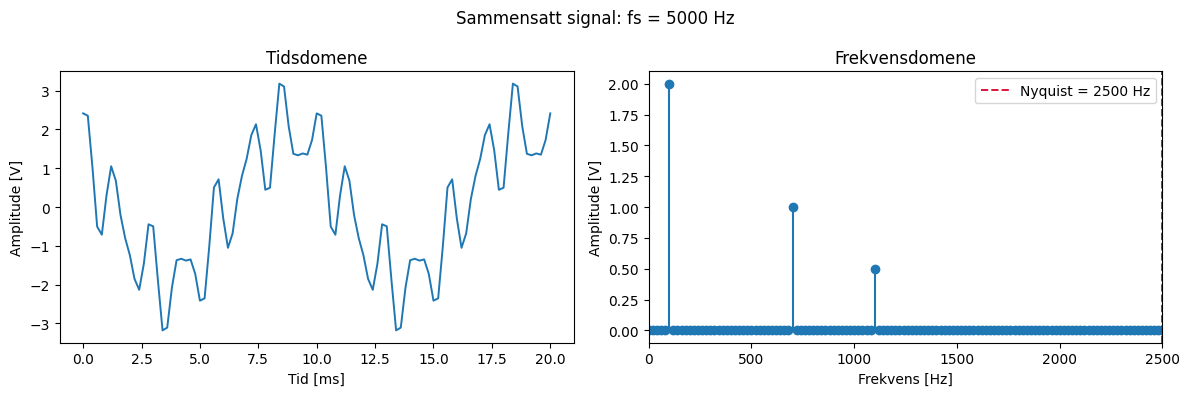

fs=5000 Hz, Nyquist=  2500 Hz, forventede frekvenser=[100.0, 700.0, 1100.0]


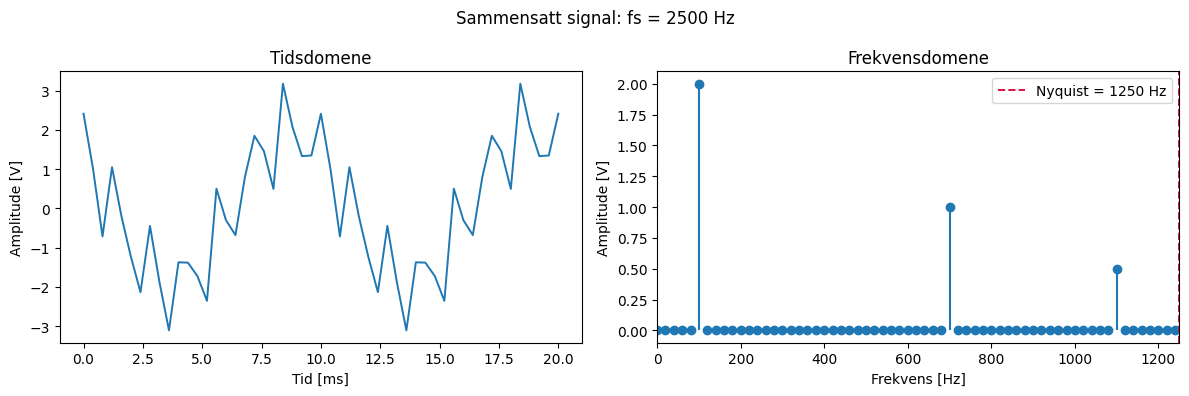

fs=2500 Hz, Nyquist=  1250 Hz, forventede frekvenser=[100.0, 700.0, 1100.0]


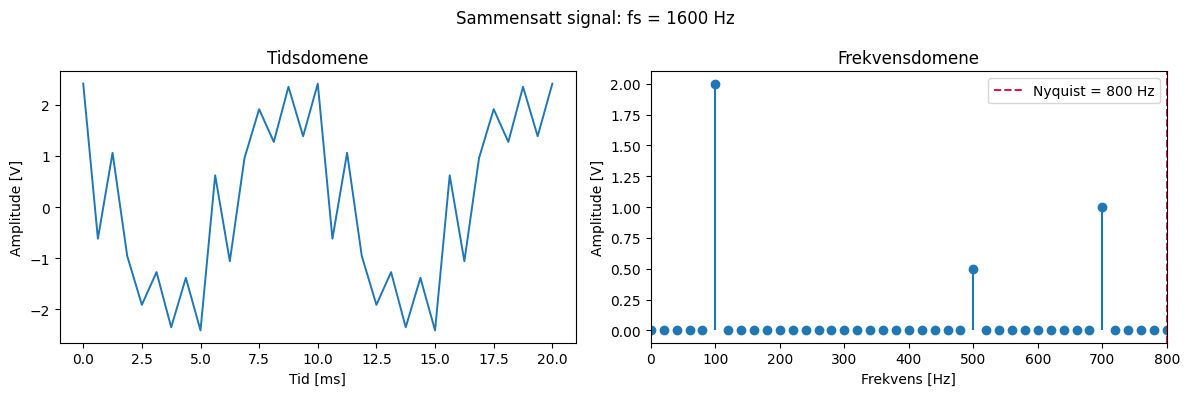

fs=1600 Hz, Nyquist=   800 Hz, forventede frekvenser=[100.0, 700.0, 500.0]


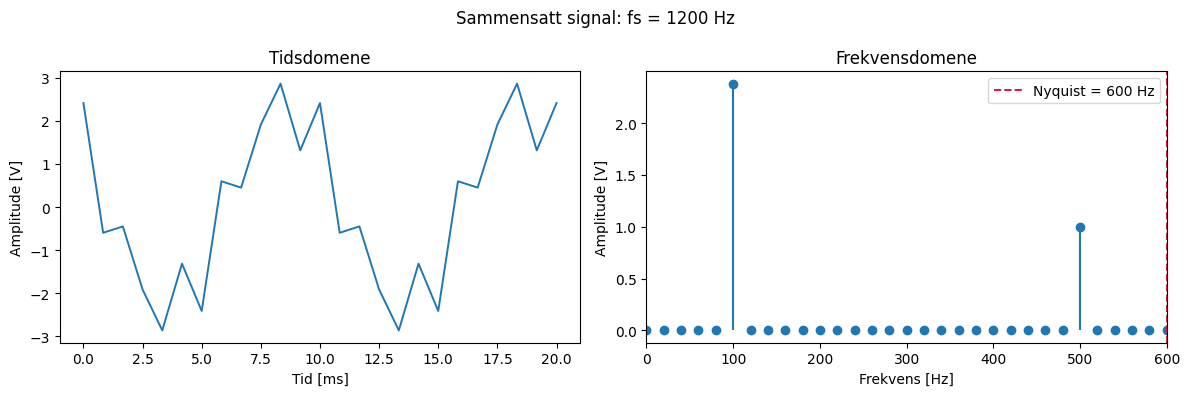

fs=1200 Hz, Nyquist=   600 Hz, forventede frekvenser=[100.0, 500.0, 100.0]


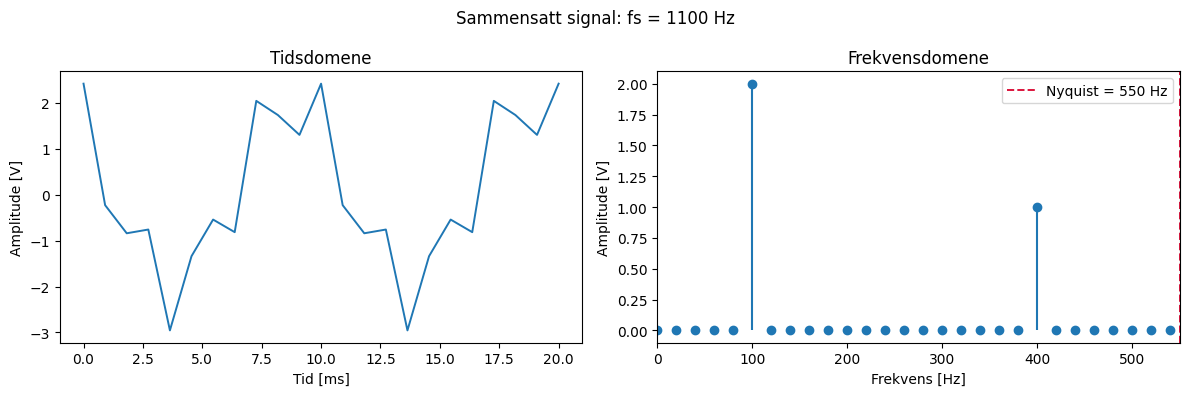

fs=1100 Hz, Nyquist=   550 Hz, forventede frekvenser=[100.0, 400.0, 0.0]


In [11]:
Alias()

**Figur 2:**
Figuren viser tidsplott og enkeltsidig amplitudespekter til de fem målingene med samplingsfrekvensene 5000 Hz, 2500 Hz, 1600 Hz, 1200 Hz og 1100 Hz.




### 2.3 Firkantsignal

Ser at ved å øke antall harmoniske, blir signalet flatere ved toppen og bunnen av signalet. Altså mer firkantformet. Med 2 Harmoniske har signalet to "pigger" i hver topp og bunn. disse flates ut og blir mer buet når antall harmoniske settes til 5. man kan også se at frekvenskomponentenes amplituder ved 5 harmoniske er høyere. Dette kommer av at de øvrige harmoniske blir foldet ned til 500 Hz og 1500 Hz.

Når samplingsfrekvensen skrus ned ser man at signalet blir dårligere representert i tidsdomenet, fordi det tas færre målepunkter per periode. Samtidig synker Nyquist-frekvensen, slik at flere av de harmoniske komponentene havner over Nyquist-grensen og foldes tilbake som aliasfrekvenser. Ved lavere samplingsfrekvenser begynner aliasering å oppstå, og ved samplingsfrekvens 1200 Hz ser man nye frekvenskomponenter ved 300 Hz og 100 Hz. Med samplingsfrekvens 1000 Hz blir signalet nesten null fordi harmonikkene samples i punkter som sammenfaller med sinusens nullpunkter.

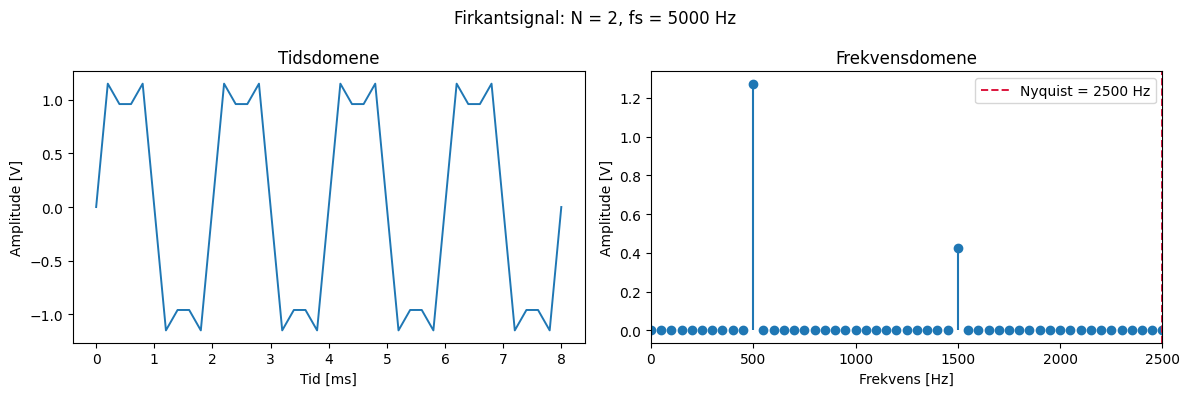

fs = 5000 Hz
  Under Nyquist: [500, 1500]
  På Nyquist: []
  Over Nyquist: []
  Aliasfrekvenser: []


In [17]:
ANTALL_HARMONISKE = 2
SAMPLINGSFREKVENSER = [5000]
firkantsignal()

**Figur 3:**
Figuren viser tidsplott og enkeltsidig amplitudespekter til frikantsignal med samplingfrekvens 5000 Hz og 2 harmoniske. Figuren viser også hvilke frekvenser som er over og under Nyquist-frekvensen, i tillegg til hvilke frekvenser som er foldet.

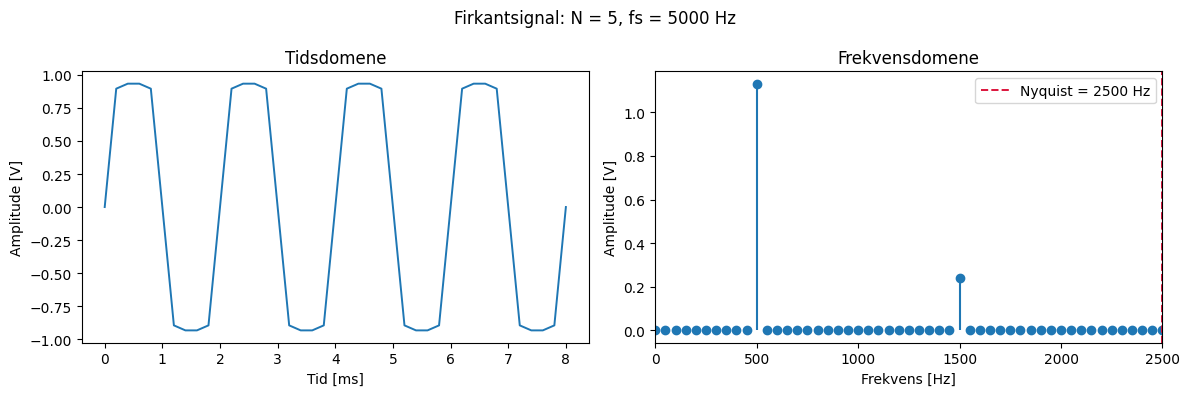

fs = 5000 Hz
  Under Nyquist: [500, 1500]
  På Nyquist: [2500]
  Over Nyquist: [3500, 4500]
  Aliasfrekvenser: [1500.0, 500.0]


In [18]:
ANTALL_HARMONISKE = 5
SAMPLINGSFREKVENSER = [5000]
firkantsignal()

**Figur 4:**
Figuren viser tidsplott og enkeltsidig amplitudespekter til firkantsignal med samplingfrekvens 5000 hz og 5 harmoniske. Figuren viser også hvilke frekvenser som er over og under Nyquist-frekvensen, i tillegg til hvilke frekvenser som er foldet.

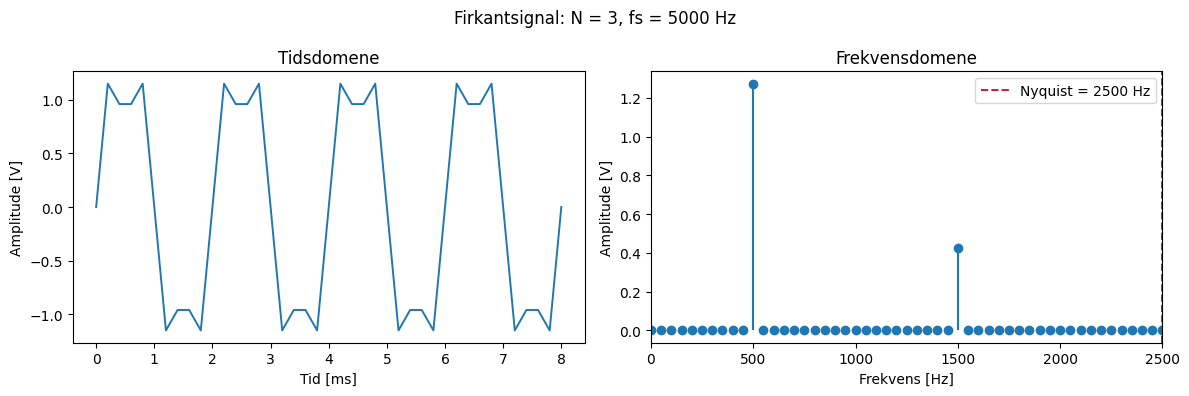

fs = 5000 Hz
  Under Nyquist: [500, 1500]
  På Nyquist: [2500]
  Over Nyquist: []
  Aliasfrekvenser: []


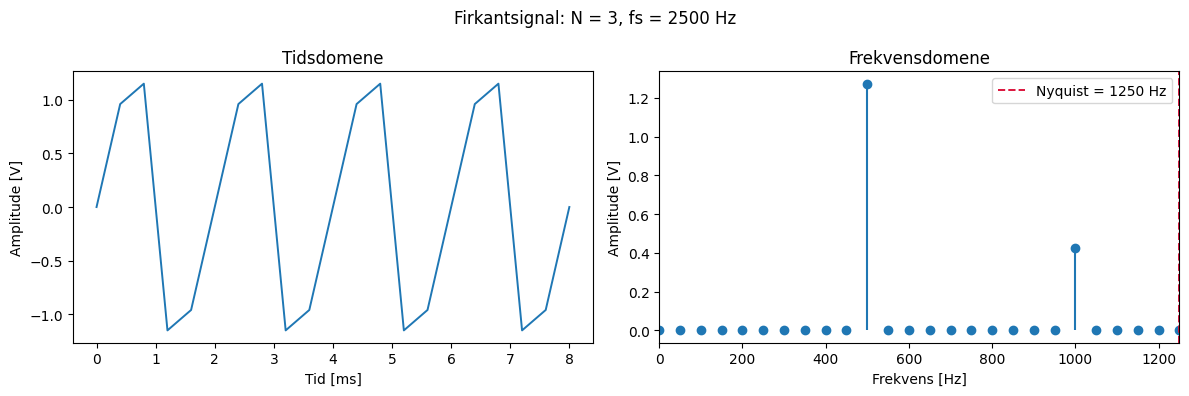

fs = 2500 Hz
  Under Nyquist: [500]
  På Nyquist: []
  Over Nyquist: [1500, 2500]
  Aliasfrekvenser: [1000.0, 0.0]


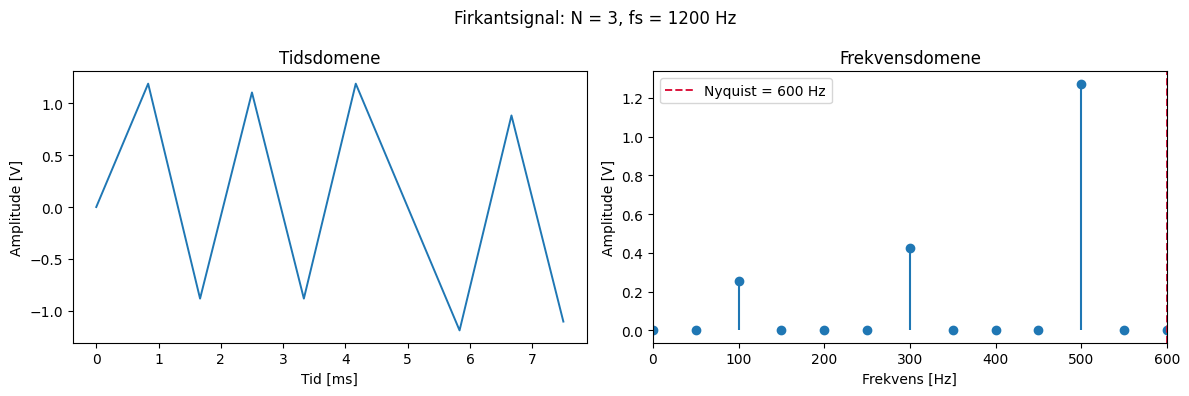

fs = 1200 Hz
  Under Nyquist: [500]
  På Nyquist: []
  Over Nyquist: [1500, 2500]
  Aliasfrekvenser: [300.0, 100.0]


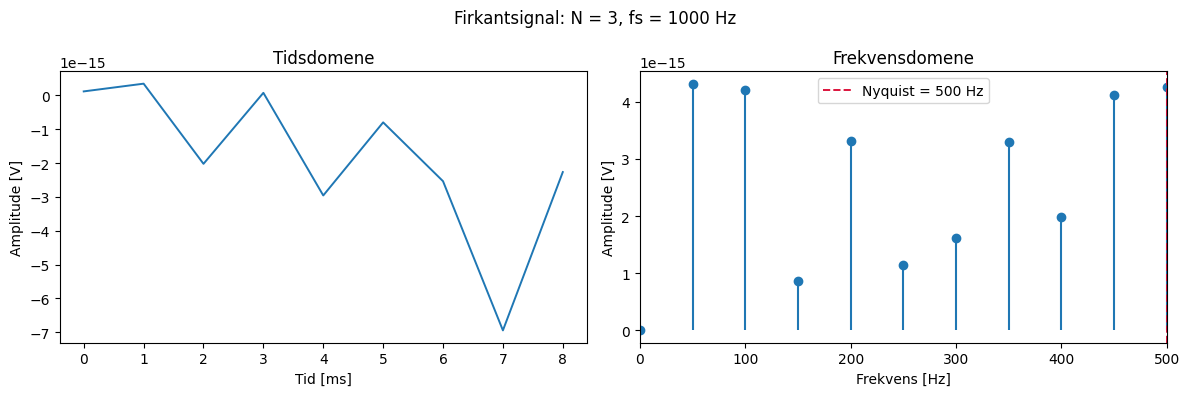

fs = 1000 Hz
  Under Nyquist: []
  På Nyquist: [500]
  Over Nyquist: [1500, 2500]
  Aliasfrekvenser: [500.0, 500.0]


In [21]:
ANTALL_HARMONISKE = 3
SAMPLINGSFREKVENSER = [5000, 2500, 1200, 1000]
firkantsignal()

**Figur 5:**
Figuren viser tidsplott og enkeltsidig amplitudespekter til firkantsignal med samplingsfrekvensene 5000 Hz, 2500 Hz, 1200 Hz og 1000 Hz, og 3 harmoniske. Figuren viser også hvilke frekvenser som er over og under Nyquist-frekvensen, i tillegg til hvilke frekvenser som er foldet.

## 3. Diskusjon

Resultatene stemmer godt overens med det som forventes fra teorien om sampling og Fourier-transformasjon. For referansesignalet viser FFT-spekteret tydelige topper ved 100 Hz, 700 Hz og 1100 Hz, med målte amplituder på henholdsvis 2,0 V, 1,0 V og 0,5 V. Dette er de samme frekvensene og amplitudene som ble brukt til å generere signalet. Frekvensoppløsningen var 20 Hz, og alle de valgte frekvensene ligger nøyaktig på FFT-binverdier. Dette gjør at sannsynligheten for at de ikke passer overens er veldig liten.

Aliasing oppstår når en frekvenskomponent ligger over Nyquist-frekvensen,

$$ f_N=\frac{f_s}{2}. $$

Ved f_s = 5000 Hz og 2500 Hz ligger alle de tre frekvenskomponentene under Nyquist-frekvensen, og spekteret er derfor uendret. Når samplingsfrekvensen reduseres til 1600 Hz, blir Nyquist-frekvensen 800 Hz. Komponenten på 1100 Hz kan da ikke representeres riktig og observeres i stedet som en aliasfrekvens på 500 Hz. Ved f_s = 1200 Hz foldes 700 Hz til 500 Hz og 1100 Hz til 100 Hz. Den siste faller dermed på samme frekvens som den opprinnelige 100 Hz-komponenten og de to bidragene kombineres. Amplituden ved 100 Hz blir derfor annerledes enn amplituden til den opprinnelige komponenten alene. Aliasing kan altså øke amplituden på eksisterende frekvenskomponenter.

For firkantsignalet stemmer resultatene også med Fourier-teorien. Et ideelt firkantsignal består av odde harmoniske,

$$ f_n=(2n-1)f_0, $$

med amplituder som avtar som

$$ A_n=\frac{4A}{\pi(2n-1)}. $$

Når flere harmoniske tas med, blir signalet derfor mer firkantformet i tidsdomenet. Samtidig inneholder signalet høyere frekvenser, som krever en tilsvarende høy samplingsfrekvens for å kunne representeres uten aliasing. Ved f_s = 5000 Hz og tre harmoniske forventes frekvensene 500, 1500 og 2500 Hz. Komponenten på 2500 Hz ligger nøyaktig på Nyquist-frekvensen, men den vises ikke som en tydelig topp i FFT-spekteret. Dette skyldes at komponentene i dette forsøket er sinusformede. Ved sampling nøyaktig to ganger per periode treffes sinusens nullpunkter. Dermed bidrar ikke 2500 Hz-komponenten til det samplede signalet. Dette er altså ikke en feil i FFT-beregningen, men et resultat av fase og plasseringen av samplingspunktene.

Når fem harmoniske brukes ved f_s = 5000 Hz, ligger 3500 Hz og 4500 Hz over Nyquist-frekvensen og foldes til henholdsvis 1500 Hz og 500 Hz. Disse aliasene havner på frekvenser som allerede finnes i signalet. Ved foldingen vil også fase påvirkes, derfor kan komponentene delvis motvirke de opprinnelige harmoniske. Dette kan forklare hvorfor FFT-amplitudene ved 500 og 1500 Hz ikke lenger er de samme som amplitudene som ble satt inn før sampling. Ved f_s=1200 Hz med tre harmoniske blir 1500 Hz foldet til 300 Hz, mens 2500 Hz foldes til 100 Hz. Dette stemmer tydelig med FFT-spekteret, hvor topper ved 100, 300 og 500 Hz observeres. Tidsformen ligner samtidig mye mindre på et firkantsignal gjerne fordi antallet samplingspunkter per periode er lavt og de høyere harmoniske er aliasert.

Det mest spesielle resultatet skjer derimot ved f_s=1000 Hz. Grunnfrekvensen på 500 Hz ligger da akkurat på Nyquist-frekvensen, mens de andre harmoniske også foldes til 500 Hz. Siden alle komponentene er sinusformede vil de, akkurat som nevnt over, samples  i eller svært nær nullpunktene. Det beregnede signalet får derfor amplituder i verdier rundt 10^(-15) V. I praksis er dette likt null. De små verdiene og FFT-toppene som fortsatt vises skyldes numerisk avrundingsfeil i programmet som er brukt, og funksjonene brukt for å plotte signalene har zoomet inn til denne skalaen.

## 4. Konklusjon

I denne laboppgaven ble sampling og FFT brukt til å undersøke signaler i tids- og frekvensdomenet. Resultatene viste at FFT gjenga de forventede frekvenskomponentene godt når samplingsfrekvensen var høy nok. Ved for lav samplingsfrekvens oppstod aliasing, der høye frekvenser ble foldet ned til lavere frekvenser. Resultatene fulgte altså teorien godt, uten noen merkbare unntak.

Det gruppen har lært er hvordan aliasing folder høyere frekvenskomponenter, og hvordan dette påvirker signalet som blir samplet. Aliasing ble observert, overlapp av frekvenskomponenter og endring av signalform ved for lav samplingsfrekvens, firkantsignal mistet sin form. Det mest interessante var å undersøke hvordan et signal ble endret med samplingsfrekvens nær Nyquist-grensen.

